<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/SPI_6_SARIMA_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Author: Kumar Puran Tripathy (PhD, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                       ARIMA TIME SERIES ANALYSIS                            ║
# ║     Date-based Split (Train: 1901–1989 | Test: 1990–2018)                    ║
# ║         Original Series | ACF/PACF | (Next: Differencing & ARIMA)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install statsmodels openpyxl


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools    import adfuller, acf, pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a', 'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569', 'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8', 'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0', 'grid.color':       '#334155',
    'grid.linestyle':   '--',      'grid.alpha':        0.5,
    'font.family':      'monospace','axes.titlesize':   11,
    'axes.labelsize':   10,        'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})
AMBER  = '#f59e0b'; GREEN  = '#34d399'; BLUE  = '#60a5fa'
ROSE   = '#f87171'; PURPLE = '#a78bfa'; SLATE = '#94a3b8'
LEAD_COLORS = ['#f87171','#fb923c','#fbbf24','#34d399','#38bdf8','#c084fc']
LEAD_LABELS = ['Lead-1','Lead-2','Lead-3','Lead-4','Lead-5','Lead-6']

# ─── HELPER: custom ACF/PACF plot ─────────────────────────────────────────────
def styled_acf_pacf(series, title, filename, nlags=40, color=BLUE):
    series = series.dropna()
    acf_vals,  acf_ci  = acf (series, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold')

    for ax, vals, ci, lbl in [
        (axes[0], acf_vals, acf_ci, 'ACF'),
        (axes[1], pacf_vals, pacf_ci, 'PACF')
    ]:
        cil = ci[:, 0] - vals
        ciu = ci[:, 1] - vals
        ax.fill_between(lags, cil, ciu, alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)
        for lag in lags[1:]:
            c = ROSE if (vals[lag] < cil[lag] or vals[lag] > ciu[lag]) else SLATE
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)
        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)
        ax.set_xlabel('Lag'); ax.set_ylabel(lbl)
        ax.set_title(f'{lbl}', color=color, fontweight='bold')
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show(); print(f"  ✓ Saved: {filename}")




In [4]:
from google.colab import files
uploaded = files.upload()

Saving Climate division 1.xlsx to Climate division 1.xlsx



  Training : 1980-01-01 → 2009-12-01  (360 months)
  Test     : 2010-01-01  → 2018-11-01  (107 months)
  Train stats: mean=0.123  std=0.910  min=-2.090  max=2.570


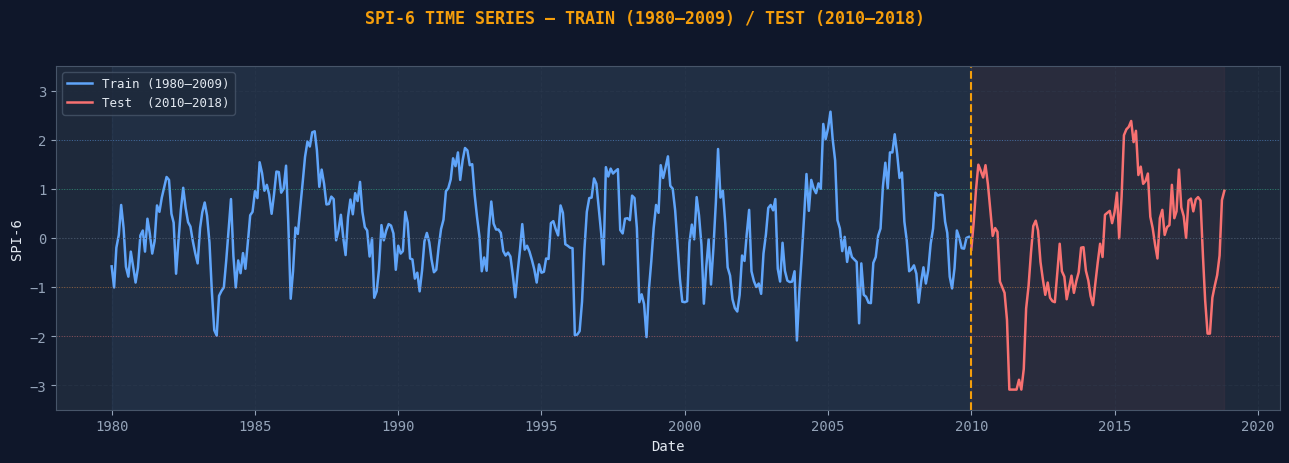

In [9]:


df_raw = pd.read_excel('Climate division 1.xlsx', header=0)
if any(str(c).startswith("Unnamed") for c in df_raw.columns):
    df_raw.columns = df_raw.iloc[0]
    df_raw = df_raw.drop(0).reset_index(drop=True)

df = df_raw.copy()
df['YearMonth'] = df['YearMonth'].astype(str).str.strip()
df['Year']  = df['YearMonth'].str[:4].astype(int)
df['Month'] = df['YearMonth'].str[4:].astype(int)
df['Date']  = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').set_index('Date')
df = df.replace([-99.99, -9999, -999.9, -99.9], np.nan)

y = df['SP06'].astype(float)
train = y.loc['1980-01-01':'2009-12-01'].dropna()
test  = y.loc['2010-01-01':].dropna()
n_train = len(train); n_test = len(test)

print(f"\n  Training : {train.index.min().date()} → {train.index.max().date()}  ({n_train} months)")
print(f"  Test     : {test.index.min().date()}  → {test.index.max().date()}  ({n_test} months)")
print(f"  Train stats: mean={train.mean():.3f}  std={train.std():.3f}  "
      f"min={train.min():.3f}  max={train.max():.3f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('SPI-6 TIME SERIES — TRAIN (1980–2009) / TEST (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)
ax.plot(train.index, train.values, color=BLUE, lw=1.8, label='Train (1980–2009)')
ax.plot(test.index,  test.values,  color=ROSE, lw=1.8, label='Test  (2010–2018)')
split_date = pd.to_datetime('2010-01-01')
ax.axvline(split_date, color=AMBER, lw=1.5, ls='--')
ax.axhline(0, color='#475569', lw=0.8, ls=':')
ax.fill_betweenx([-3.5, 3.5], train.index.min(), split_date, alpha=0.05, color=BLUE)
ax.fill_betweenx([-3.5, 3.5], split_date, test.index.max(),  alpha=0.05, color=ROSE)
# SPI threshold lines
for val, lbl, c in [(-2,'Extreme Dry',ROSE),(-1,'Moderate Dry','#fb923c'),
                     (1,'Moderate Wet',GREEN),(2,'Extreme Wet',BLUE)]:
    ax.axhline(val, color=c, lw=0.7, ls=':', alpha=0.5)
ax.set_ylabel('SPI-6'); ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_ylim(-3.5, 3.5)
plt.tight_layout()
# plt.savefig('01_spi6_train_test_split.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')



  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)


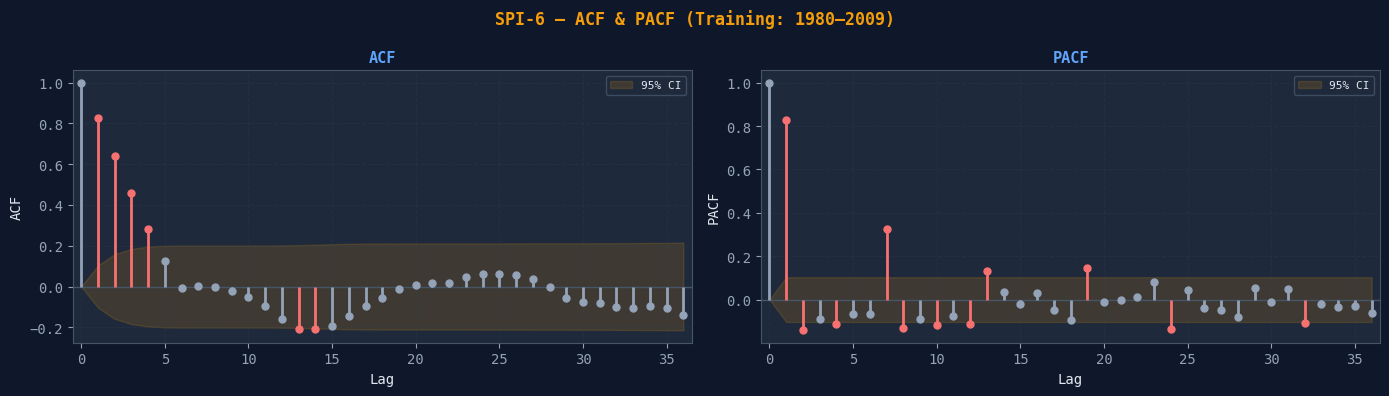

  ✓ Saved: 02_spi6_acf_pacf_train.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ACF / PACF + ADF TEST (TRAINING DATA)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)")
print("=" * 70)

styled_acf_pacf(train, 'SPI-6 — ACF & PACF (Training: 1980–2009)',
                '02_spi6_acf_pacf_train.png', nlags=36, color=BLUE)

adf = adfuller(train, autolag='AIC')



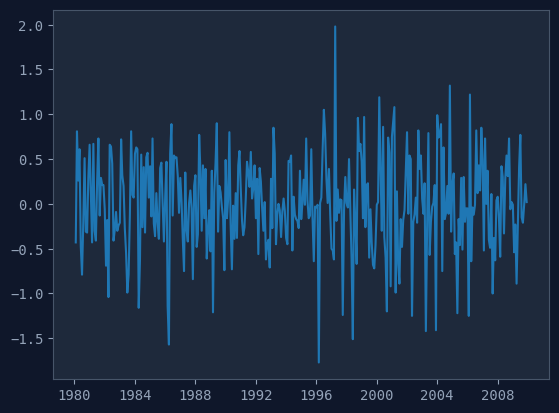

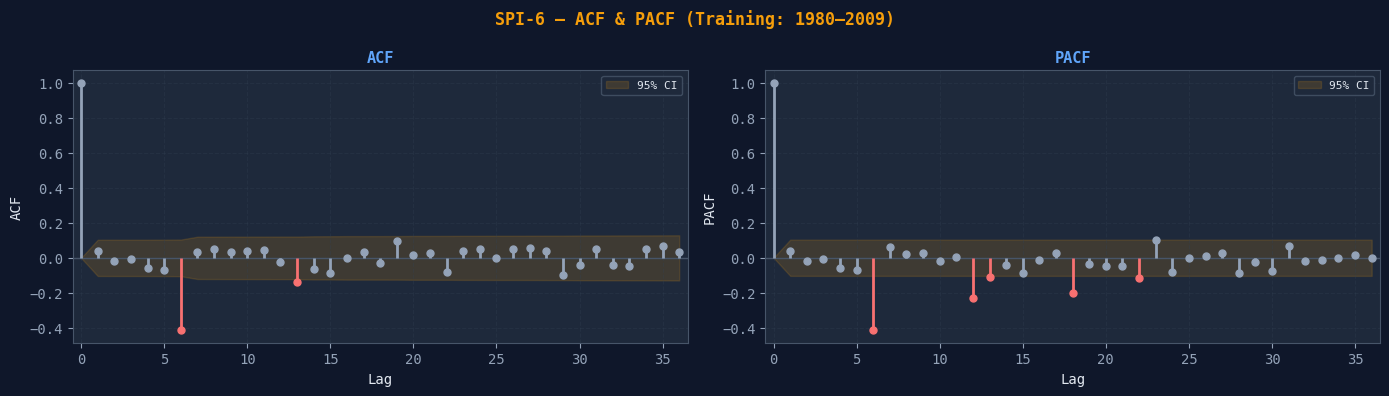

  ✓ Saved: 02_spi6_acf_pacf_train.png


In [16]:
train_diff1 = train.diff().dropna()
plt.plot(train_diff1)
styled_acf_pacf(train_diff1, 'SPI-6 — ACF & PACF (Training: 1980–2009)',
                '02_spi6_acf_pacf_train.png', nlags=36, color=BLUE)


  Model (p,d,q)(P,D,Q,s)              AIC        BIC       HQIC     LogLik         σ²
  ──────────────────────────────────────────────────────────────────────────
  SARIMA(1, 1, 0)(0, 0, 1, 6)     459.580    471.171    464.193   -226.790     0.2143
  SARIMA(2, 1, 0)(0, 0, 1, 6)     460.120    475.575    466.270   -226.060     0.2132
  SARIMA(1, 1, 0)(1, 0, 0, 6)     493.522    505.112    498.134   -243.761     0.2364
  SARIMA(2, 1, 0)(1, 0, 0, 6)     491.780    507.223    497.926   -241.890     0.2362
  SARIMA(0, 1, 1)(0, 0, 1, 6)     458.487    470.070    463.097   -226.244     0.2145
  SARIMA(0, 1, 2)(0, 0, 1, 6)     458.961    474.393    465.104   -225.481     0.2140
  SARIMA(0, 1, 1)(1, 0, 0, 6)     494.505    506.104    499.121   -244.253     0.2365
  SARIMA(1, 1, 1)(0, 0, 1, 6)     460.012    475.455    466.158   -226.006     0.2173
  SARIMA(1, 1, 1)(1, 0, 0, 6)     492.996    508.451    499.147   -242.498     0.2390
  SARIMA(2, 1, 1)(0, 0, 1, 6)     450.052    469.356    457.73

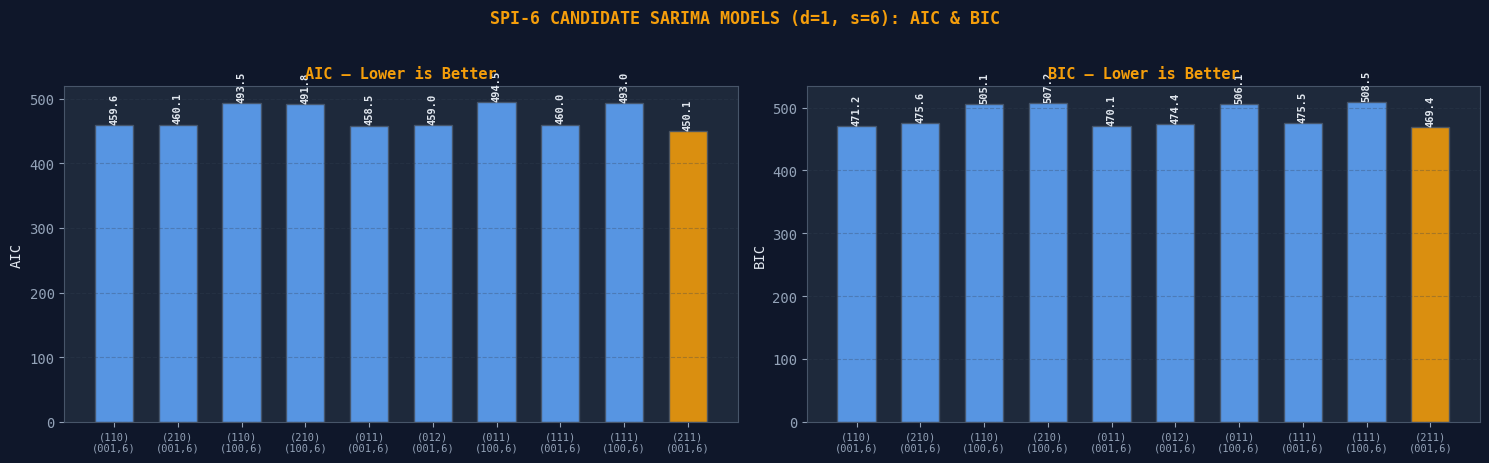

  ✓ Saved: 03_spi6_sarima_model_comparison.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — SPI-6 CANDIDATE SARIMA MODELS (d=1, s=6): AIC / BIC
# ══════════════════════════════════════════════════════════════════════════════
# After d=1 differencing:
#   - Mean ≈ 0, constant variance  → stationary ✓
#   - ACF: negative spike at lag 6       → seasonal MA(1) at s=6
#   - PACF: negative spikes at 6,12,18   → seasonal AR component at s=6
#   - Regular part: mostly white noise after lag 0 → low p,q
#   - Seasonal period s=6 (SPI-6 has 6-month rolling window → natural cycle)
#
# Candidate structure: SARIMA(p, 1, q)(P, 0, Q)_6
#   d=1   → regular differencing confirmed by ADF + visual
#   D=0   → seasonal differencing NOT needed (d=1 already stabilised mean)
#   s=6   → seasonal period = 6 months
# ──────────────────────────────────────────────────────────────────────────────

from statsmodels.tsa.statespace.sarimax import SARIMAX

# (p, d, q) , (P, D, Q, s)
candidate_orders = [
    # ── Non-seasonal AR dominant (PACF spike at lag 1) ──────────────────
    ((1,1,0), (0,0,1,6)),   # AR(1) + seasonal MA(1)        ← strong candidate
    ((2,1,0), (0,0,1,6)),   # AR(2) + seasonal MA(1)
    ((1,1,0), (1,0,0,6)),   # AR(1) + seasonal AR(1)
    ((2,1,0), (1,0,0,6)),   # AR(2) + seasonal AR(1)

    # ── MA non-seasonal ──────────────────────────────────────────────────
    ((0,1,1), (0,0,1,6)),   # MA(1) + seasonal MA(1)
    ((0,1,2), (0,0,1,6)),   # MA(2) + seasonal MA(1)
    ((0,1,1), (1,0,0,6)),   # MA(1) + seasonal AR(1)

    # ── Mixed ARMA ───────────────────────────────────────────────────────
    ((1,1,1), (0,0,1,6)),   # ARMA(1,1) + seasonal MA(1)   ← strong candidate
    ((1,1,1), (1,0,0,6)),   # ARMA(1,1) + seasonal AR(1)
    ((2,1,1), (0,0,1,6)),   # ARMA(2,1) + seasonal MA(1)
]

model_results = {}

print(f"\n  {'Model (p,d,q)(P,D,Q,s)':<28} {'AIC':>10} {'BIC':>10} "
      f"{'HQIC':>10} {'LogLik':>10} {'σ²':>10}")
print("  " + "─" * 74)

for (order, seasonal_order) in candidate_orders:
    try:
        mod = SARIMAX(train,
                      order=order,
                      seasonal_order=seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        sig2 = np.var(mod.resid)
        label = f"SARIMA{order}{seasonal_order}"
        model_results[(order, seasonal_order)] = mod
        print(f"  {label:<28} {mod.aic:>10.3f} {mod.bic:>10.3f} "
              f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>10.4f}")
    except Exception as e:
        print(f"  SARIMA{order}{seasonal_order:<20} FAILED: {e}")

# Best by AIC
best_key = min(model_results, key=lambda k: model_results[k].aic)
best_order, best_seasonal = best_key
print(f"\n  ✓ Best model by AIC : SARIMA{best_order}{best_seasonal}")
print(f"  ✓ Best model by BIC : SARIMA"
      f"{min(model_results, key=lambda k: model_results[k].bic)}")

# ── AIC / BIC bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle('SPI-6 CANDIDATE SARIMA MODELS (d=1, s=6): AIC & BIC',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

labels   = [f"({o[0]}{o[1]}{o[2]})\n({s[0]}{s[1]}{s[2]},{s[3]})"
            for o, s in candidate_orders if (o,s) in model_results]
keys_ok  = [(o,s) for o,s in candidate_orders if (o,s) in model_results]
aic_vals = [model_results[k].aic for k in keys_ok]
bic_vals = [model_results[k].bic for k in keys_ok]
bar_cols = [AMBER if k == best_key else BLUE for k in keys_ok]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'),
                          (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(range(len(labels)), vals, color=bar_cols,
                  edgecolor='#475569', width=0.6, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 0.04*(max(vals)-min(vals)),
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5,
                color='#e2e8f0', fontweight='bold', rotation=90)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_spi6_sarima_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 03_spi6_sarima_model_comparison.png")


  SECTION 4: BEST SARIMA — FIT ONCE ON TRAINING DATA

  ── Model: SARIMA(2, 1, 1)(0, 0, 1, 6) ───────────────────────
  ── Fixed Coefficients (fit on training only) ───────────────────
    φ₁ (ar.L1)        = +0.965623
    φ₂ (ar.L2)        = -0.072824
    θ₁ (ma.L1)        = -0.999993
    Θ₁ (sma.L6)     = -0.571493
    θ₁·Θ₁ (cross)     = +0.571489
    σ²                = 0.210428

  ── EQUATION DERIVATION (SARIMA in backshift notation) ────────────────

  General form:
    φ(B)·Φ(B^s)·(1−B)^d·Yₜ = c + θ(B)·Θ(B^s)·εₜ      [s = 6]

  For SARIMA(2,1,1)(0,0,1,6) — expanding all operators:

  Step 1 — let wₜ = Yₜ − Yₜ₋₁  (first difference, d=1):

    (1 − φ₁B)·wₜ = c + (1 + θ₁B)·(1 + Θ₁B^6)·εₜ

  Step 2 — expand the MA side:

    wₜ = c + φ₁·wₜ₋₁ + εₜ + θ₁·εₜ₋₁ + Θ₁·εₜ₋6 + θ₁Θ₁·εₜ₋7

  Step 3 — substitute wₜ = Yₜ − Yₜ₋₁ and rearrange for Ŷₜ:

    Ŷₜ = Yₜ₋₁
         + +0.0000
         + (+0.9656) · (Yₜ₋₁ − Yₜ₋₂)     ← AR(1) on differences
         + (-1.0000) · εₜ₋₁                ← MA(1

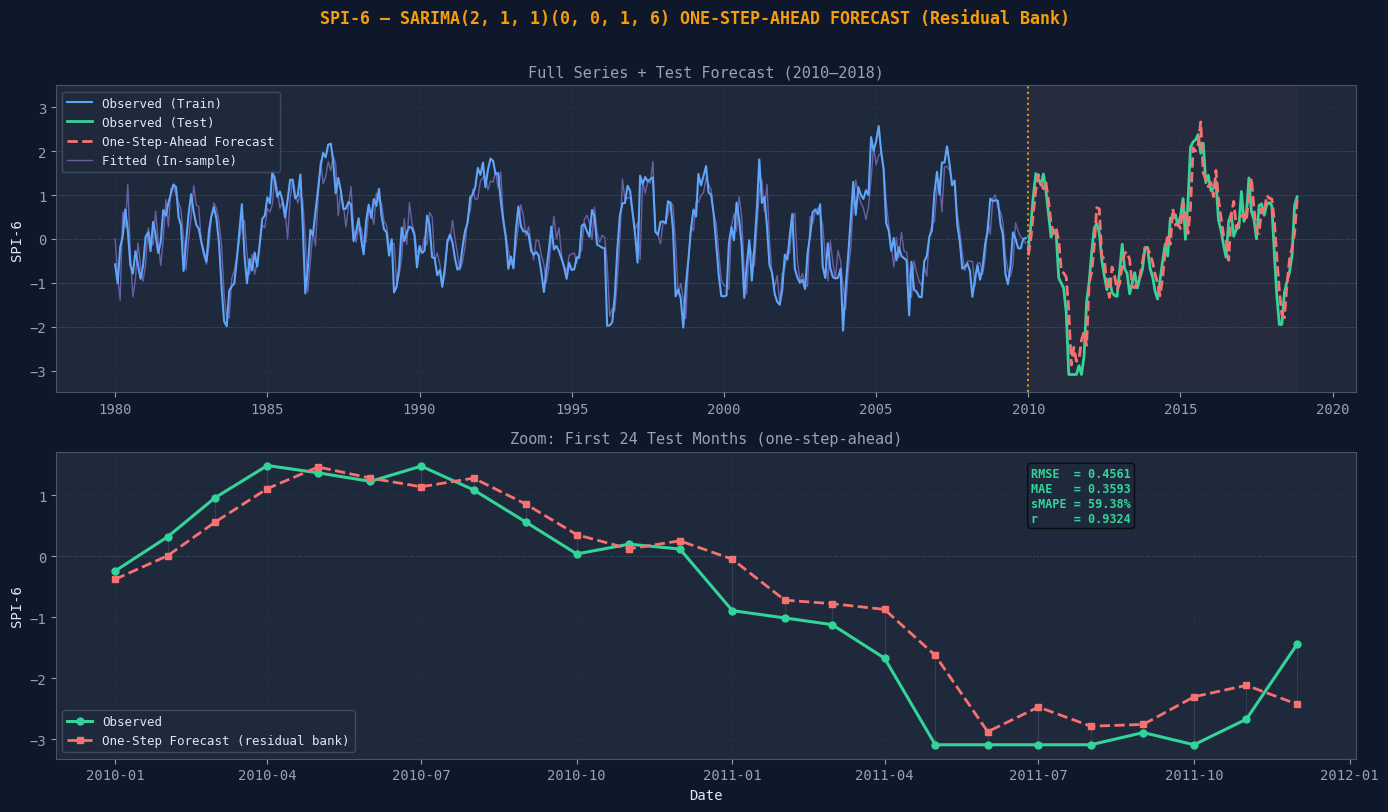

  ✓ Saved: 04_spi6_forecast_plot.png


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BEST SARIMA: FIT ONCE ON TRAINING DATA
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 4: BEST SARIMA — FIT ONCE ON TRAINING DATA")
print("=" * 70)

# best_key = ((p,d,q),(P,D,Q,s)) — already identified in Section 3 by AIC
(p_ord, d_ord, q_ord), (P_ord, D_ord, Q_ord, s_ord) = best_key

final_model = SARIMAX(train,
                      order          = (p_ord, d_ord, q_ord),
                      seasonal_order = (P_ord, D_ord, Q_ord, s_ord),
                      enforce_stationarity = False,
                      enforce_invertibility= False).fit(disp=False)

# ── Extract every coefficient by name ────────────────────────────────────────
pnames = list(final_model.param_names)
pmap   = dict(zip(pnames, final_model.params))

c_       = pmap.get('intercept', pmap.get('const', 0.0))
phi1     = pmap.get('ar.L1',  0.0)
phi2     = pmap.get('ar.L2',  0.0)
th1      = pmap.get('ma.L1',  0.0)
th2      = pmap.get('ma.L2',  0.0)
PHI1     = pmap.get(f'ar.S.L{s_ord}',  0.0)    # seasonal AR(1)
TH1      = pmap.get(f'ma.S.L{s_ord}',  0.0)    # seasonal MA(1)
cross_th1_TH1 = th1 * TH1                      # interaction term θ₁·Θ₁
sigma2   = np.var(final_model.resid)

print(f"\n  ── Model: SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} ───────────────────────")
print(f"  ── Fixed Coefficients (fit on training only) ───────────────────")
if abs(c_)            > 1e-10: print(f"    c  (intercept)    = {c_:+.6f}")
if abs(phi1)          > 1e-10: print(f"    φ₁ (ar.L1)        = {phi1:+.6f}")
if abs(phi2)          > 1e-10: print(f"    φ₂ (ar.L2)        = {phi2:+.6f}")
if abs(th1)           > 1e-10: print(f"    θ₁ (ma.L1)        = {th1:+.6f}")
if abs(th2)           > 1e-10: print(f"    θ₂ (ma.L2)        = {th2:+.6f}")
if abs(PHI1)          > 1e-10: print(f"    Φ₁ (sar.L{s_ord})     = {PHI1:+.6f}")
if abs(TH1)           > 1e-10: print(f"    Θ₁ (sma.L{s_ord})     = {TH1:+.6f}")
if abs(cross_th1_TH1) > 1e-10: print(f"    θ₁·Θ₁ (cross)     = {cross_th1_TH1:+.6f}")
print(f"    σ²                = {sigma2:.6f}")

print(f"""
  ── EQUATION DERIVATION (SARIMA in backshift notation) ────────────────

  General form:
    φ(B)·Φ(B^s)·(1−B)^d·Yₜ = c + θ(B)·Θ(B^s)·εₜ      [s = {s_ord}]

  For SARIMA({p_ord},{d_ord},{q_ord})({P_ord},{D_ord},{Q_ord},{s_ord}) — expanding all operators:

  Step 1 — let wₜ = Yₜ − Yₜ₋₁  (first difference, d=1):

    (1 − φ₁B)·wₜ = c + (1 + θ₁B)·(1 + Θ₁B^{s_ord})·εₜ

  Step 2 — expand the MA side:

    wₜ = c + φ₁·wₜ₋₁ + εₜ + θ₁·εₜ₋₁ + Θ₁·εₜ₋{s_ord} + θ₁Θ₁·εₜ₋{s_ord+1}

  Step 3 — substitute wₜ = Yₜ − Yₜ₋₁ and rearrange for Ŷₜ:

    Ŷₜ = Yₜ₋₁
         + {c_:+.4f}
         + ({phi1:+.4f}) · (Yₜ₋₁ − Yₜ₋₂)     ← AR(1) on differences
         + ({th1:+.4f}) · εₜ₋₁                ← MA(1)
         + ({TH1:+.4f}) · εₜ₋{s_ord}              ← seasonal MA(1) at s={s_ord}
         + ({cross_th1_TH1:+.4f}) · εₜ₋{s_ord+1}     ← cross term θ₁·Θ₁

  Residual bank requirements:
    εₜ₋₁  →  1 step back   (enters test bank after step 1)
    εₜ₋{s_ord}  →  {s_ord} steps back  (enters test bank after step {s_ord})
    εₜ₋{s_ord+1}  →  {s_ord+1} steps back  (enters test bank after step {s_ord+1})
""")

print(final_model.summary())


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — ONE-STEP-AHEAD FORECASTING — RESIDUAL BANK
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 5: ONE-STEP-AHEAD FORECASTING — RESIDUAL BANK METHOD")
print("=" * 70)

train_vals = train.values.astype(float)
test_vals  = test.values.astype(float)
y_all      = np.concatenate([train_vals, test_vals])
n_train    = len(train_vals)
n_test     = len(test_vals)

# ── Seed residual bank with training residuals ────────────────────────────────
resid_bank = list(final_model.resid.values)   # ε₁ … ε_{n_train}

print(f"\n  Residual bank seeded with {len(resid_bank)} training residuals.")
print(f"  Fixed coefficients: φ₁={phi1:+.4f}  θ₁={th1:+.4f}  "
      f"Θ₁={TH1:+.4f}  θ₁Θ₁={cross_th1_TH1:+.4f}\n")

forecasts = []

print(f"  {'Date':>10}  {'Yₜ₋₁':>8}  {'Yₜ₋₂':>8}  "
      f"{'εₜ₋₁(src)':>11}  {'εₜ₋₆(src)':>11}  {'εₜ₋₇':>8}  "
      f"{'Ŷₜ':>9}  {'Yₜ':>8}  {'εₜ':>8}")
print("  " + "─" * 105)

for step in range(n_test):
    t_idx = n_train + step          # 0-based position in y_all

    # ── AR lags: ALWAYS actual observed ──────────────────────────────────
    y_tm1 = y_all[t_idx - 1]        # Yₜ₋₁
    y_tm2 = y_all[t_idx - 2]        # Yₜ₋₂  (for AR-on-differences term)

    # ── MA lags from residual bank ────────────────────────────────────────
    eps_tm1      = resid_bank[t_idx - 1]           # εₜ₋₁
    eps_tm_s     = resid_bank[t_idx - s_ord]        # εₜ₋₆  seasonal lag
    eps_tm_s1    = resid_bank[t_idx - s_ord - 1]    # εₜ₋₇  cross term lag

    # ── Apply forecasting equation (levels form) ──────────────────────────
    w_tm1 = y_tm1 - y_tm2
    y_hat = (y_tm1
             + c_
             + phi1         * w_tm1
             + th1          * eps_tm1
             + TH1          * eps_tm_s
             + cross_th1_TH1 * eps_tm_s1)

    # ── Observe actual, compute εₜ, extend bank ──────────────────────────
    y_obs = y_all[t_idx]
    eps_t = y_obs - y_hat
    resid_bank.append(eps_t)

    abs_pct = abs(eps_t / y_obs) * 100 if abs(y_obs) > 0.01 else np.nan
    forecasts.append({
        'Date':    test.index[step],
        'Y_tm1':   y_tm1,
        'Y_tm2':   y_tm2,
        'eps_tm1': eps_tm1,
        'eps_tms': eps_tm_s,
        'eps_tms1':eps_tm_s1,
        'Y_hat':   round(y_hat, 5),
        'Y_obs':   round(y_obs, 5),
        'Error':   round(eps_t, 5),
        'AbsPct':  round(abs_pct, 3) if np.isfinite(abs_pct) else np.nan,
    })

    # Print first 24 + last 6
    if step < 24 or step >= n_test - 6:
        date_str = test.index[step].strftime('%Y-%m')
        src1 = 'TR' if (t_idx - 1)     < n_train else 'TS'
        src6 = 'TR' if (t_idx - s_ord) < n_train else 'TS'
        print(f"  {date_str:>10}  {y_tm1:>8.4f}  {y_tm2:>8.4f}  "
              f"{eps_tm1:>8.4f}({src1})  {eps_tm_s:>8.4f}({src6})  "
              f"{eps_tm_s1:>8.4f}  {y_hat:>9.4f}  {y_obs:>8.4f}  {eps_t:>8.4f}")
    elif step == 24:
        print("  ...")

df_fc = pd.DataFrame(forecasts)

# ── Accuracy metrics ──────────────────────────────────────────────────────────
rmse  = np.sqrt(np.mean(df_fc['Error']**2))
mae   = np.mean(np.abs(df_fc['Error']))
bias  = np.mean(df_fc['Error'])
r, _  = stats.pearsonr(df_fc['Y_obs'], df_fc['Y_hat'])
smape = np.mean(200 * np.abs(df_fc['Error']) /
                (np.abs(df_fc['Y_obs']) + np.abs(df_fc['Y_hat']) + 1e-8))

print(f"\n  ── One-Step-Ahead Accuracy ─────────────────────────────────────")
print(f"    RMSE      = {rmse:.5f}")
print(f"    MAE       = {mae:.5f}")
print(f"    sMAPE     = {smape:.3f}%  (robust near zero)")
print(f"    Bias      = {bias:.5f}  "
      f"{'(over-forecast)' if bias < 0 else '(under-forecast)'}")
print(f"    Pearson r = {r:.5f}")

# ── Show which bank each ε came from ─────────────────────────────────────────
print(f"""
  ── Residual bank source (first {min(s_ord+2, 10)} steps) ──────────────────
  Step │ εₜ₋₁ from   │ εₜ₋{s_ord} from  │ εₜ₋{s_ord+1} from
  ─────┼─────────────┼─────────────┼─────────────""")
for step in range(min(s_ord + 2, n_test)):
    t_idx = n_train + step
    s1  = 'Training' if t_idx - 1       < n_train else f'Test ε_{t_idx-1-n_train+1}'
    s6  = 'Training' if t_idx - s_ord   < n_train else f'Test ε_{t_idx-s_ord-n_train+1}'
    s7  = 'Training' if t_idx - s_ord-1 < n_train else f'Test ε_{t_idx-s_ord-1-n_train+1}'
    print(f"  {step+1:>4} │ {s1:<11} │ {s6:<11} │ {s7}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — OBSERVED vs ONE-STEP-AHEAD FORECAST PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 6: OBSERVED vs ONE-STEP-AHEAD FORECAST")
print("=" * 70)

fitted_train = final_model.fittedvalues
full_hat     = pd.Series(df_fc['Y_hat'].values, index=pd.to_datetime(df_fc['Date']))
split_date   = test.index.min()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    f'SPI-6 — SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} '
    f'ONE-STEP-AHEAD FORECAST (Residual Bank)',
    fontsize=12, color=AMBER, fontweight='bold', y=1.01)

# ── Top panel: full series ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(train.index, train.values, color=BLUE,   lw=1.5,
        label='Observed (Train)', zorder=3)
ax.plot(test.index,  test.values,  color=GREEN,  lw=2.0,
        label='Observed (Test)',  zorder=3)
ax.plot(full_hat.index, full_hat.values, color=ROSE, lw=2.0, ls='--',
        label='One-Step-Ahead Forecast', zorder=4)
ax.plot(fitted_train.index, fitted_train.values, color=PURPLE, lw=1.0,
        alpha=0.55, label='Fitted (In-sample)', zorder=2)
ax.axvline(split_date, color=AMBER, lw=1.5, ls=':', alpha=0.9)
ax.axhline(0, color='#475569', lw=0.8, ls=':')
for val, c in [(-2, ROSE), (-1, '#fb923c'), (1, GREEN), (2, BLUE)]:
    ax.axhline(val, color=c, lw=0.6, ls=':', alpha=0.4)
ax.fill_betweenx([-3.5, 3.5], split_date, test.index.max(),
                  alpha=0.04, color=ROSE)
ax.set_ylabel('SPI-6')
ax.set_title(f'Full Series + Test Forecast ({test.index.min().year}–{test.index.max().year})',
             color=SLATE)
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_ylim(-3.5, 3.5)

# ── Bottom panel: zoom first 24 test months ───────────────────────────────────
ax2 = axes[1]
zoom_end  = test.index[min(23, n_test - 1)]
obs_zoom  = pd.concat([train, test]).sort_index().loc[split_date:zoom_end]
hat_zoom  = full_hat.loc[split_date:zoom_end]

ax2.plot(obs_zoom.index, obs_zoom.values, color=GREEN, lw=2.2,
         marker='o', ms=5, label='Observed', zorder=3)
ax2.plot(hat_zoom.index, hat_zoom.values, color=ROSE,  lw=2.0,
         marker='s', ms=4, ls='--',
         label='One-Step Forecast (residual bank)', zorder=4)
for dt in obs_zoom.index:
    if dt in hat_zoom.index:
        ax2.vlines(dt,
                   min(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   max(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   color='#475569', lw=0.8, alpha=0.5)
ax2.axhline(0, color='#475569', lw=0.8, ls=':')
ax2.set_xlabel('Date'); ax2.set_ylabel('SPI-6')
ax2.set_title('Zoom: First 24 Test Months (one-step-ahead)', color=SLATE)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.text(0.75, 0.95,
         f'RMSE  = {rmse:.4f}\nMAE   = {mae:.4f}\n'
         f'sMAPE = {smape:.2f}%\nr     = {r:.4f}',
         transform=ax2.transAxes, color=GREEN, fontsize=8.5, va='top',
         fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.7))

plt.tight_layout()
plt.savefig('04_spi6_forecast_plot.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 04_spi6_forecast_plot.png")


  SECTION 7: FORECAST EVALUATION — SCATTER & ERROR BARS


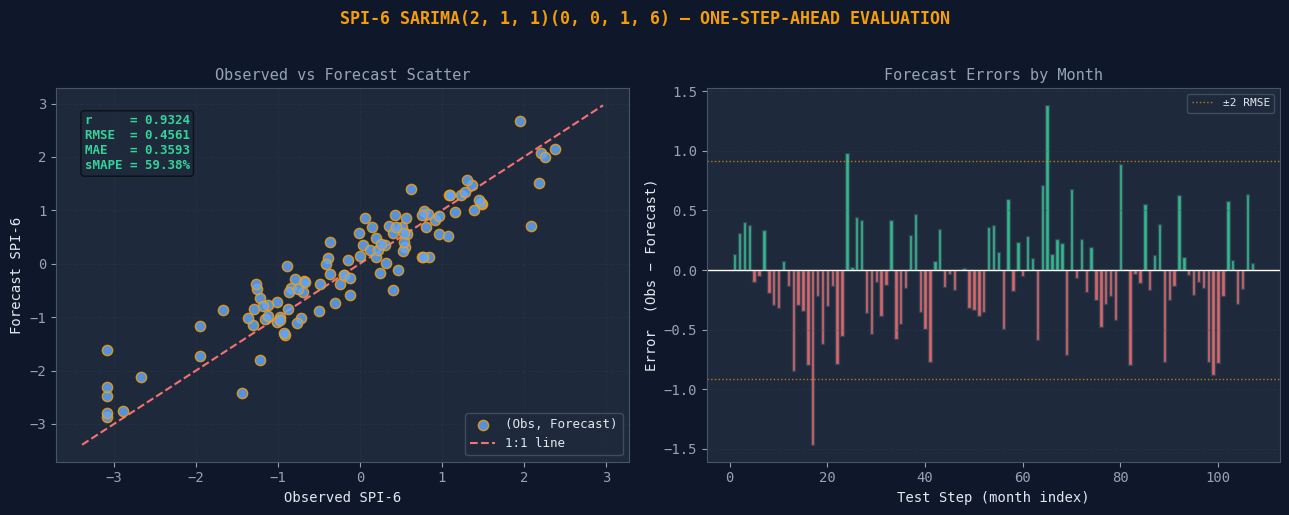

  ✓ Saved: 05_spi6_forecast_evaluation.png


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — SCATTER + ERROR BARS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 7: FORECAST EVALUATION — SCATTER & ERROR BARS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'SPI-6 SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} '
    f'— ONE-STEP-AHEAD EVALUATION',
    fontsize=12, color=AMBER, fontweight='bold', y=1.02)

# ── Scatter ───────────────────────────────────────────────────────────────────
ax = axes[0]
obs  = df_fc['Y_obs'].values
pred = df_fc['Y_hat'].values
ax.scatter(obs, pred, color=BLUE, edgecolors=AMBER, s=55, alpha=0.85,
           zorder=3, label='(Obs, Forecast)')
lims = [min(obs.min(), pred.min()) - 0.3, max(obs.max(), pred.max()) + 0.3]
ax.plot(lims, lims, color=ROSE, lw=1.5, ls='--', label='1:1 line')
ax.set_xlabel('Observed SPI-6'); ax.set_ylabel('Forecast SPI-6')
ax.set_title('Observed vs Forecast Scatter', color=SLATE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.text(0.05, 0.93,
        f'r     = {r:.4f}\nRMSE  = {rmse:.4f}\n'
        f'MAE   = {mae:.4f}\nsMAPE = {smape:.2f}%',
        transform=ax.transAxes, color=GREEN, fontsize=9,
        fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.6))

# ── Error bars ────────────────────────────────────────────────────────────────
ax2 = axes[1]
errors     = df_fc['Error'].values
colors_err = [GREEN if e >= 0 else ROSE for e in errors]
ax2.bar(range(1, len(errors) + 1), errors, color=colors_err,
        edgecolor='#334155', width=0.7, alpha=0.85)
ax2.axhline(0,      color='white', lw=1)
ax2.axhline(+2*rmse, color=AMBER, lw=1, ls=':', alpha=0.7, label='±2 RMSE')
ax2.axhline(-2*rmse, color=AMBER, lw=1, ls=':', alpha=0.7)
ax2.set_xlabel('Test Step (month index)')
ax2.set_ylabel('Error  (Obs − Forecast)')
ax2.set_title('Forecast Errors by Month', color=SLATE)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_spi6_forecast_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 05_spi6_forecast_evaluation.png")





  SECTION 8: RESIDUAL DIAGNOSTICS (Training Residuals)


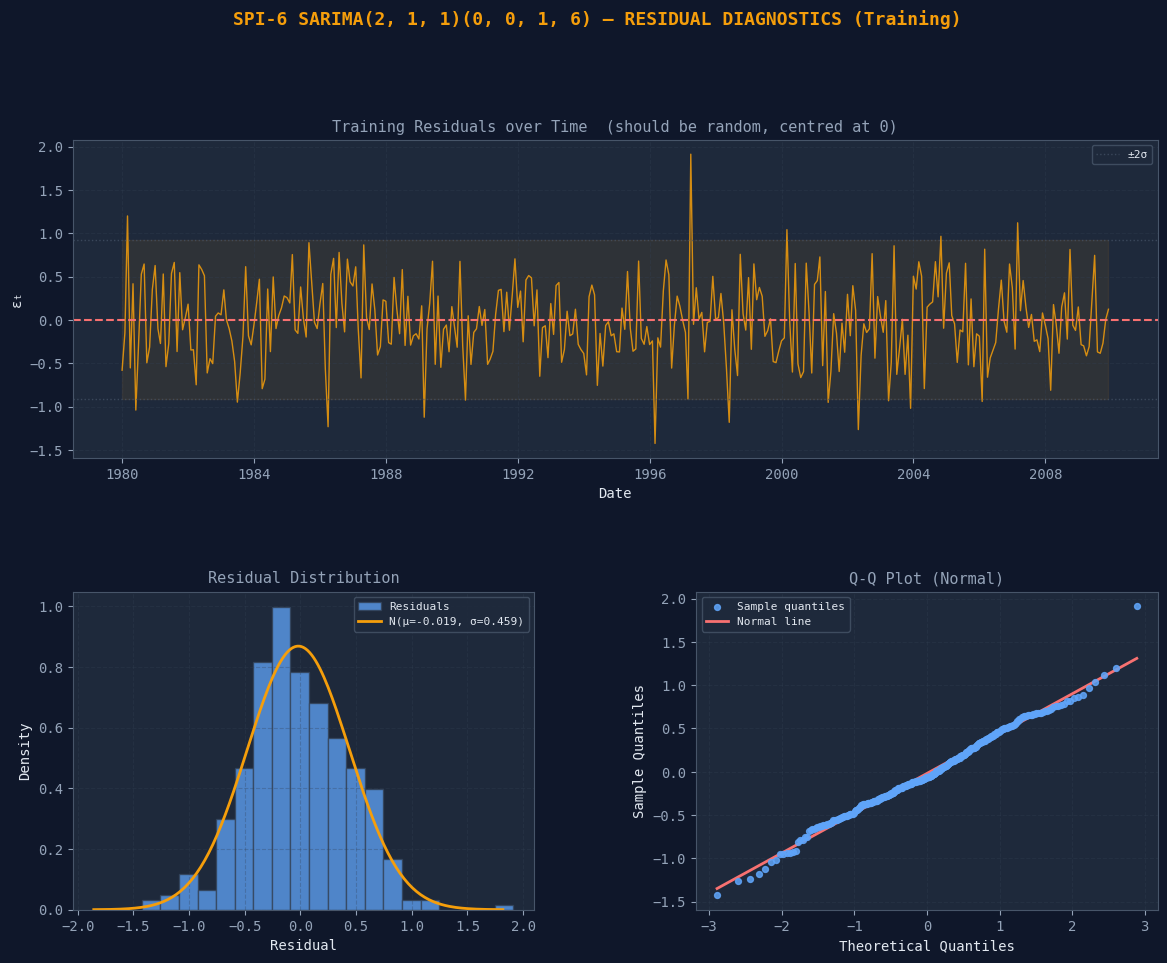

  ✓ Saved: 06_spi6_diagnostics.png


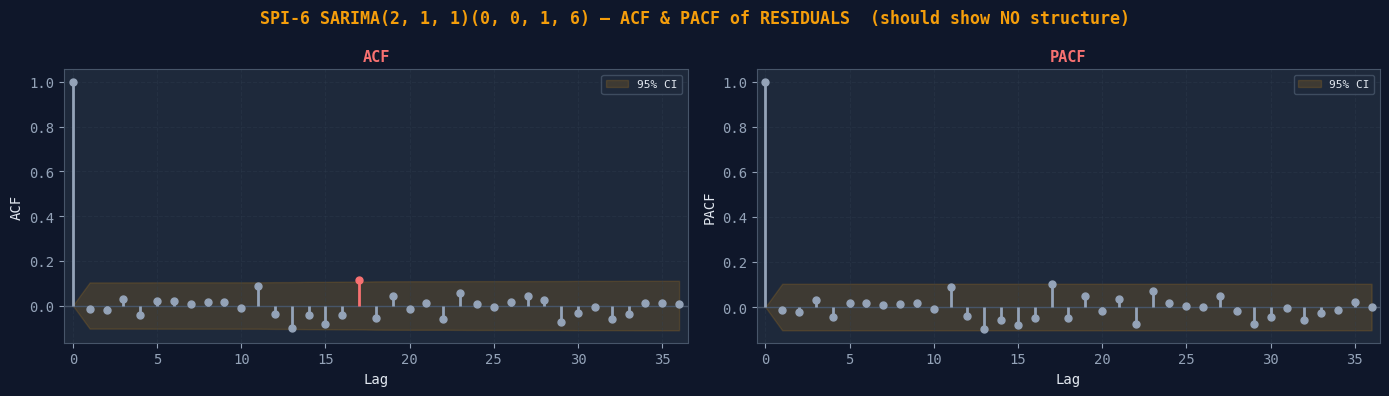

  ✓ Saved: 07_spi6_resid_acf_pacf.png


In [22]:


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — RESIDUAL DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 8: RESIDUAL DIAGNOSTICS (Training Residuals)")
print("=" * 70)

residuals = final_model.resid.dropna()

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f'SPI-6 SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} '
    f'— RESIDUAL DIAGNOSTICS (Training)',
    fontsize=13, color=AMBER, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# 1) Residuals vs time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals.index, residuals.values, color=AMBER, lw=1.0, alpha=0.85)
ax1.axhline(0, color=ROSE, lw=1.5, ls='--')
sig = np.std(residuals.values)
ax1.axhline(+2*sig, color='#475569', lw=1, ls=':', alpha=0.7, label='±2σ')
ax1.axhline(-2*sig, color='#475569', lw=1, ls=':', alpha=0.7)
ax1.fill_between(residuals.index, -2*sig, 2*sig, alpha=0.08, color=AMBER)
ax1.set_xlabel('Date'); ax1.set_ylabel('εₜ')
ax1.set_title('Training Residuals over Time  (should be random, centred at 0)',
              color=SLATE)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2) Histogram + normal overlay
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals.values, bins=20, color=BLUE, edgecolor='#334155',
         alpha=0.75, density=True, label='Residuals')
mu_r, std_r = residuals.mean(), residuals.std()
xr = np.linspace(mu_r - 4*std_r, mu_r + 4*std_r, 200)
ax2.plot(xr, stats.norm.pdf(xr, mu_r, std_r), color=AMBER, lw=2,
         label=f'N(μ={mu_r:.3f}, σ={std_r:.3f})')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution', color=SLATE)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3) Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, _) = stats.probplot(residuals.values, dist='norm')
ax3.scatter(osm, osr, color=BLUE, s=18, alpha=0.85, zorder=3,
            label='Sample quantiles')
ax3.plot(osm, slope * np.array(osm) + intercept, color=ROSE, lw=2,
         label='Normal line')
ax3.set_xlabel('Theoretical Quantiles'); ax3.set_ylabel('Sample Quantiles')
ax3.set_title('Q-Q Plot (Normal)', color=SLATE)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.savefig('06_spi6_diagnostics.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 06_spi6_diagnostics.png")

# ── ACF/PACF of residuals ─────────────────────────────────────────────────────
styled_acf_pacf(
    residuals,
    f'SPI-6 SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} '
    f'— ACF & PACF of RESIDUALS  (should show NO structure)',
    '07_spi6_resid_acf_pacf.png',
    nlags=36, color=ROSE)



  SECTION 9: MULTI-STEP LEAD COMPARISON (Lead 1–6)

    Lead       RMSE        MAE     sMAPE%       Bias
  ────────────────────────────────────────────────────
  Lead-1    0.45614    0.35932     59.378   -0.07594
  Lead-2    0.70254    0.55526     84.939   -0.14868
  Lead-3    0.87735    0.67649     98.515   -0.22402
  Lead-4    1.03032    0.76807    105.974   -0.29715
  Lead-5    1.16615    0.86638    116.414   -0.37080
  Lead-6    1.29808    0.98424    134.023   -0.44715

  Note on MA term availability per lead (s=6):
  Lead  │ θ₁·εₜ₋₁  │ Θ₁·εₜ₋6  │ θ₁Θ₁·εₜ₋7
  ──────┼──────────┼──────────┼──────────
      1 │ KNOWN    │ KNOWN    │ KNOWN
      2 │ zero     │ KNOWN    │ KNOWN
      3 │ zero     │ KNOWN    │ KNOWN
      4 │ zero     │ KNOWN    │ KNOWN
      5 │ zero     │ KNOWN    │ KNOWN
      6 │ zero     │ KNOWN    │ KNOWN


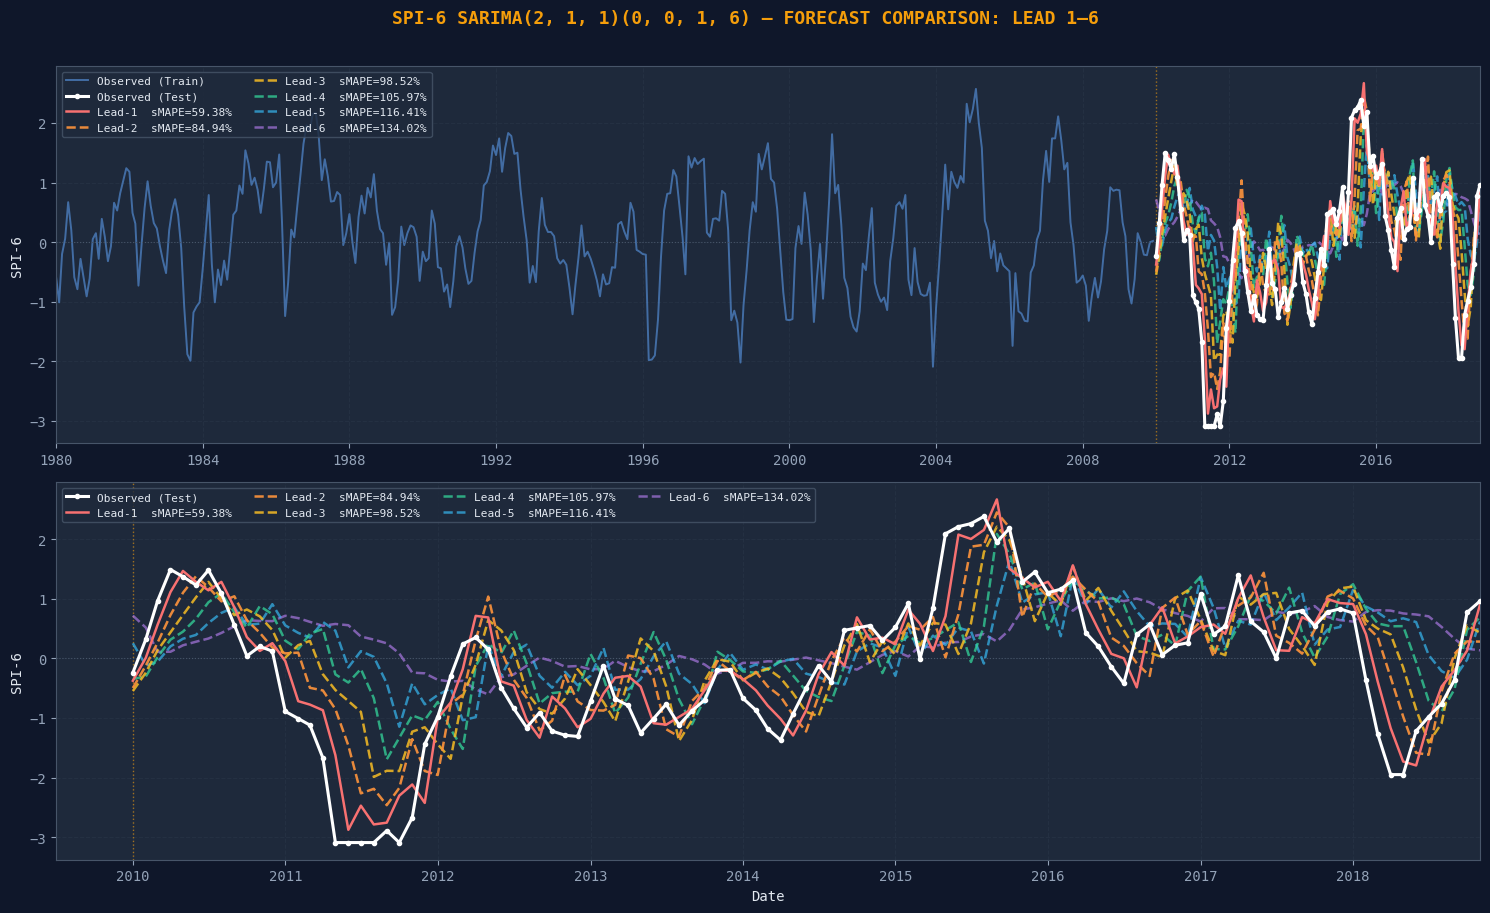

  ✓ Saved: 08_spi6_multi_lead.png


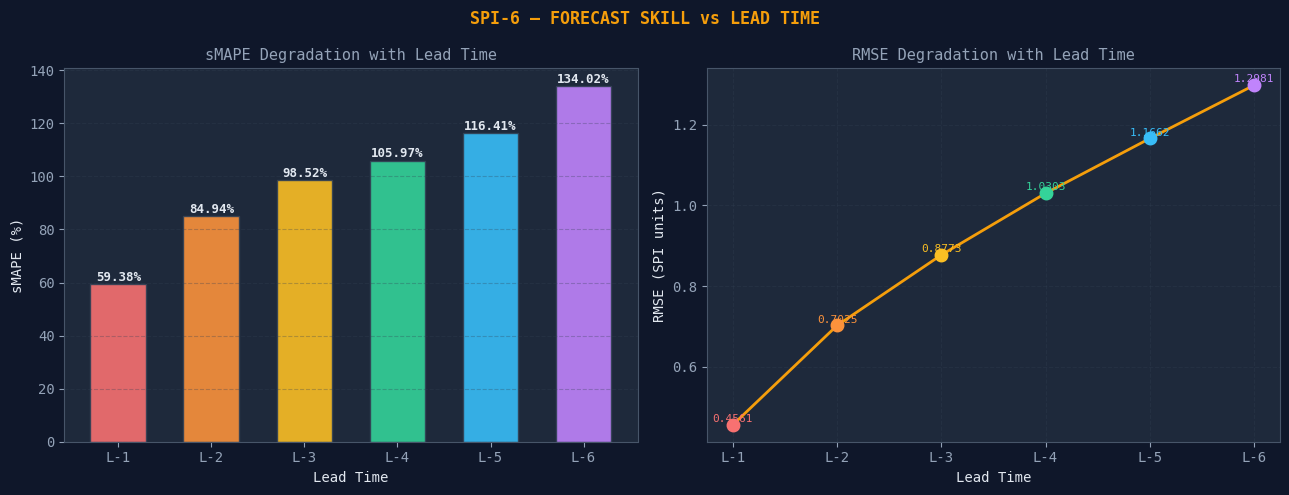

  ✓ Saved: 09_spi6_lead_skill.png


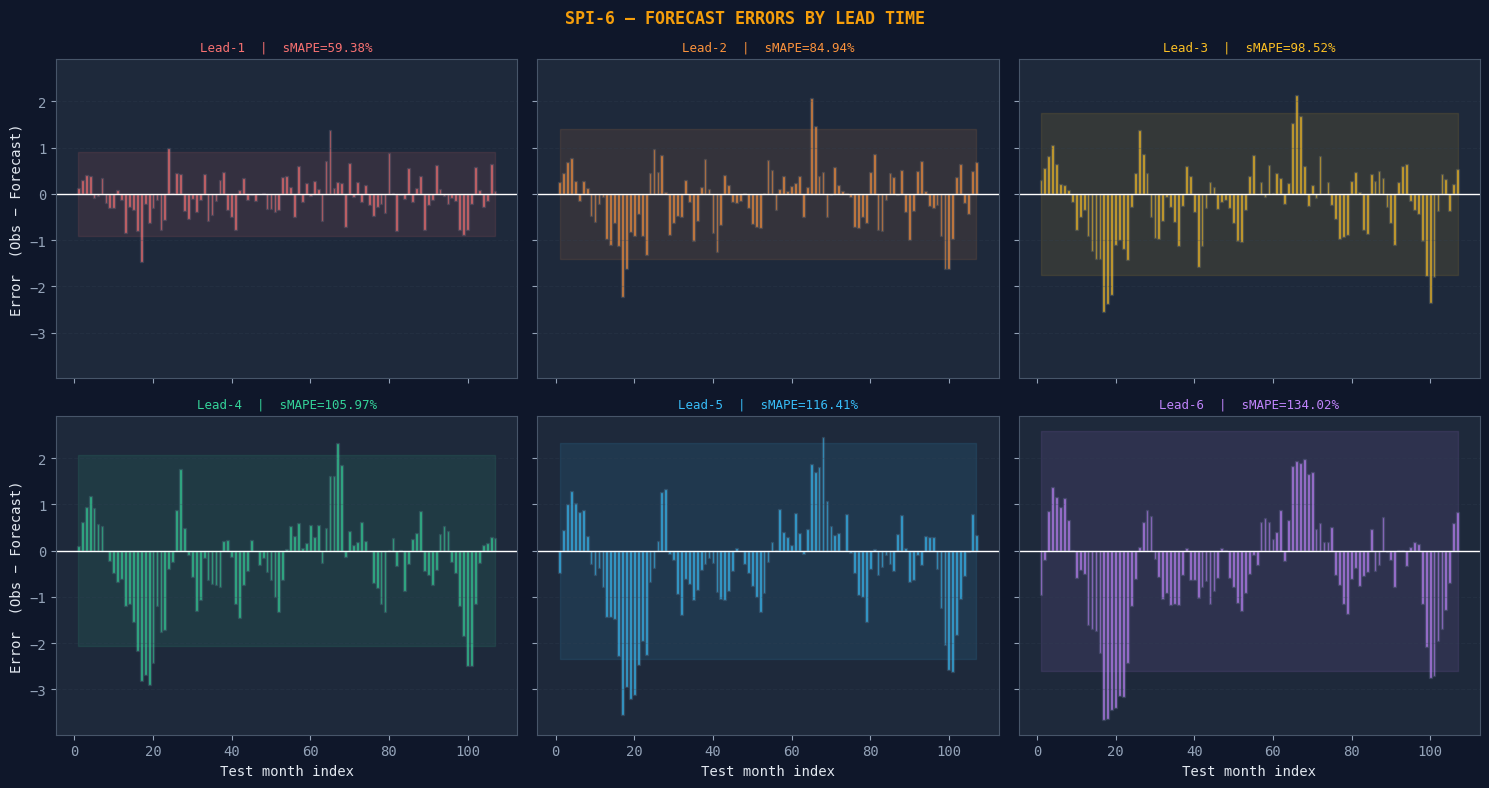

  ✓ Saved: 10_spi6_lead_error_panels.png

╔══════════════════════════════════════════════════════════════════════╗
║              SPI-6 SARIMA ANALYSIS — COMPLETE                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  Saved files:                                                        ║
║    01_spi6_train_test_split.png   — Train/test series               ║
║    02_spi6_acf_pacf_train.png     — ACF/PACF training data          ║
║    03_spi6_sarima_comparison.png  — AIC/BIC candidate models        ║
║    04_spi6_forecast_plot.png      — Observed vs forecast            ║
║    05_spi6_forecast_evaluation.png— Scatter + error bars            ║
║    06_spi6_diagnostics.png        — Residual diagnostics            ║
║    07_spi6_resid_acf_pacf.png     — ACF/PACF of residuals           ║
║    08_spi6_multi_lead.png         — Lead 1–6 forecast comparison    ║
║    09_spi6_lead_skill.png         — sMAPE/RMSE degradation          ║
║    10_spi6_lead_e

In [20]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — MULTI-STEP LEAD COMPARISON (Lead 1 – 6)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 9: MULTI-STEP LEAD COMPARISON (Lead 1–6)")
print("=" * 70)

# ── Key insight for SARIMA(1,1,1)(0,0,1)_6 multi-step ────────────────────────
# Forecast equation (levels):
#   Ŷₜ = Yₜ₋₁ + c + φ₁(Yₜ₋₁−Yₜ₋₂) + θ₁εₜ₋₁ + Θ₁εₜ₋₆ + θ₁Θ₁εₜ₋₇
#
# For Lead-h we recursively forecast h steps from origin (t-h).
# Each intermediate step appends 0.0 to buf_eps (unknown future ε = 0).
# The MA terms are picked from buf_eps → they become 0 as soon as they
# fall beyond the known residuals in the bank.
#
# Concretely for SARIMA with s=6 and MA lags at 1, 6, 7:
#   Lead-1: εₜ₋₁, εₜ₋₆, εₜ₋₇  all KNOWN from bank         → full equation
#   Lead-2: εₜ₋₁ becomes future → 0; εₜ₋₆, εₜ₋₇ known
#   Lead-6: εₜ₋₁..εₜ₋₅ → 0; εₜ₋₆, εₜ₋₇ still KNOWN
#   Lead-7: εₜ₋₁..εₜ₋₆ → 0; εₜ₋₇ still known
#   Lead-8: all MA terms → 0; model degrades to pure AR(1) on differences

MAX_LEAD = 6

def forecast_lead_h_sarima(y_all, resid_bank_full, t_idx, h,
                            c_, phi1, th1, TH1, cross_th1_TH1, s):
    """
    Lead-h forecast for SARIMA(1,1,1)(0,0,1)_s at position t_idx.

    Recursively forecasts h steps forward from origin (t_idx - h).
    buf_y   : actual levels up to and including origin
    buf_eps : residuals up to and including origin; future steps get 0.0

    Forecast equation (levels form):
      Ŷₜ = Yₜ₋₁ + c + φ₁(Yₜ₋₁−Yₜ₋₂) + θ₁εₜ₋₁ + Θ₁εₜ₋ₛ + θ₁Θ₁εₜ₋(s+1)
    """
    # seed buffers with all known data up to origin (inclusive)
    origin = t_idx - h
    buf_y   = list(y_all[:origin + 1])
    buf_eps = list(resid_bank_full[:origin + 1])

    for _ in range(h):
        n        = len(buf_y)
        y_prev   = buf_y[-1]                          # Yₜ₋₁
        y_prev2  = buf_y[-2] if n >= 2 else 0.0       # Yₜ₋₂
        w_prev   = y_prev - y_prev2                    # wₜ₋₁ = Yₜ₋₁ − Yₜ₋₂

        # pick ε lags from buf_eps; if index < 0 or beyond known → 0
        def get_eps(lag):
            idx = len(buf_eps) - lag
            return buf_eps[idx] if 0 <= idx < len(buf_eps) else 0.0

        eps_tm1   = get_eps(1)        # εₜ₋₁
        eps_tms   = get_eps(s)        # εₜ₋ₛ    (seasonal lag)
        eps_tms1  = get_eps(s + 1)    # εₜ₋(s+1) (cross term lag)

        y_hat_h = (y_prev
                   + c_
                   + phi1          * w_prev
                   + th1           * eps_tm1
                   + TH1           * eps_tms
                   + cross_th1_TH1 * eps_tms1)

        buf_y.append(y_hat_h)
        buf_eps.append(0.0)           # future ε unknown → 0

    return buf_y[-1]


# ── Build full residual bank (training + test one-step residuals) ─────────────
full_resid_bank = list(final_model.resid.values)
for row in forecasts:
    full_resid_bank.append(row['Error'])

lead_results = {}
print(f"\n  {'Lead':>6}  {'RMSE':>9}  {'MAE':>9}  {'sMAPE%':>9}  {'Bias':>9}")
print("  " + "─" * 52)

for h in range(1, MAX_LEAD + 1):
    preds_h, errors_h = [], []
    for step in range(n_test):
        t_idx   = n_train + step
        y_hat_h = forecast_lead_h_sarima(
            y_all, full_resid_bank, t_idx, h,
            c_, phi1, th1, TH1, cross_th1_TH1, s_ord)
        y_obs_h = y_all[t_idx]
        preds_h.append(y_hat_h)
        errors_h.append(y_obs_h - y_hat_h)

    arr_e   = np.array(errors_h)
    arr_o   = test_vals
    arr_p   = np.array(preds_h)
    rmse_h  = np.sqrt(np.mean(arr_e**2))
    mae_h   = np.mean(np.abs(arr_e))
    smape_h = np.mean(200 * np.abs(arr_e) /
                      (np.abs(arr_o) + np.abs(arr_p) + 1e-8))
    bias_h  = np.mean(arr_e)
    lead_results[h] = dict(preds=preds_h, errors=errors_h,
                           rmse=rmse_h, mae=mae_h,
                           smape=smape_h, bias=bias_h)
    print(f"  Lead-{h}  {rmse_h:>9.5f}  {mae_h:>9.5f}  "
          f"{smape_h:>9.3f}  {bias_h:>+9.5f}")

# ── Note on MA term drop-off ──────────────────────────────────────────────────
print(f"""
  Note on MA term availability per lead (s={s_ord}):
  Lead  │ θ₁·εₜ₋₁  │ Θ₁·εₜ₋{s_ord}  │ θ₁Θ₁·εₜ₋{s_ord+1}
  ──────┼──────────┼──────────┼──────────""")
for h in range(1, MAX_LEAD + 1):
    e1 = 'KNOWN' if h <= 1        else 'zero  '
    e6 = 'KNOWN' if h <= s_ord    else 'zero  '
    e7 = 'KNOWN' if h <= s_ord+1  else 'zero  '
    print(f"  {h:>5} │ {e1:<8} │ {e6:<8} │ {e7}")


# ── Plot A: All leads on one plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle(
    f'SPI-6 SARIMA{(p_ord,d_ord,q_ord)}{(P_ord,D_ord,Q_ord,s_ord)} '
    f'— FORECAST COMPARISON: LEAD 1–{MAX_LEAD}',
    fontsize=13, color=AMBER, fontweight='bold', y=1.01)

six_months_before = test.index.min() - pd.DateOffset(months=6)
for idx, (ax, xlims) in enumerate([
    (axes[0], (train.index.min(), test.index.max())),
    (axes[1], (six_months_before,  test.index.max())),
]):
    if idx == 0:
        ax.plot(train.index, train.values, color=BLUE, lw=1.4, alpha=0.55,
                label='Observed (Train)')
    ax.plot(test.index, test.values, color='white', lw=2.2,
            marker='o', ms=3, label='Observed (Test)', zorder=5)
    for h in range(1, MAX_LEAD + 1):
        ax.plot(test.index, lead_results[h]['preds'],
                color=LEAD_COLORS[h - 1], lw=1.8,
                ls='-' if h == 1 else '--',
                alpha=1.0 - (h - 1) * 0.08,
                label=f'{LEAD_LABELS[h-1]}  sMAPE={lead_results[h]["smape"]:.2f}%',
                zorder=4 - h * 0.1)
    ax.axvline(test.index.min(), color=AMBER, lw=1, ls=':', alpha=0.6)
    ax.axhline(0, color='#475569', lw=0.8, ls=':')
    ax.set_xlim(*xlims); ax.set_ylabel('SPI-6')
    ax.legend(fontsize=8, loc='upper left', ncol=2 if idx == 0 else 4)
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('08_spi6_multi_lead.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 08_spi6_multi_lead.png")


# ── Plot B: sMAPE & RMSE degradation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SPI-6 — FORECAST SKILL vs LEAD TIME',
             fontsize=12, color=AMBER, fontweight='bold')

leads  = list(range(1, MAX_LEAD + 1))
smapes = [lead_results[h]['smape'] for h in leads]
rmses  = [lead_results[h]['rmse']  for h in leads]

ax = axes[0]
bars = ax.bar(leads, smapes, color=LEAD_COLORS, edgecolor='#334155',
              width=0.6, alpha=0.9)
for bar, v in zip(bars, smapes):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
            f'{v:.2f}%', ha='center', va='bottom',
            fontsize=9, color='#e2e8f0', fontweight='bold')
ax.set_xlabel('Lead Time'); ax.set_ylabel('sMAPE (%)')
ax.set_title('sMAPE Degradation with Lead Time', color=SLATE)
ax.set_xticks(leads); ax.set_xticklabels([f'L-{h}' for h in leads])
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
ax2.plot(leads, rmses, color=AMBER, lw=2, marker='o', ms=7,
         markerfacecolor='#0f172a', markeredgewidth=2)
for h, r_v, c in zip(leads, rmses, LEAD_COLORS):
    ax2.plot(h, r_v, 'o', color=c, ms=9, zorder=4)
    ax2.text(h, r_v + 0.002, f'{r_v:.4f}',
             ha='center', va='bottom', fontsize=8, color=c)
ax2.set_xlabel('Lead Time'); ax2.set_ylabel('RMSE (SPI units)')
ax2.set_title('RMSE Degradation with Lead Time', color=SLATE)
ax2.set_xticks(leads); ax2.set_xticklabels([f'L-{h}' for h in leads])
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('09_spi6_lead_skill.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 09_spi6_lead_skill.png")


# ── Plot C: Error panels per lead ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
fig.suptitle('SPI-6 — FORECAST ERRORS BY LEAD TIME',
             fontsize=12, color=AMBER, fontweight='bold')
for idx, h in enumerate(range(1, MAX_LEAD + 1)):
    ax    = axes[idx // 3][idx % 3]
    errs  = np.array(lead_results[h]['errors'])
    color = LEAD_COLORS[h - 1]
    ax.bar(range(1, n_test + 1), errs, color=color,
           edgecolor='#334155', width=0.7, alpha=0.8)
    ax.axhline(0, color='white', lw=1)
    ax.fill_between(range(1, n_test + 1),
                    -2 * lead_results[h]['rmse'],
                     2 * lead_results[h]['rmse'],
                    alpha=0.1, color=color)
    ax.set_title(
        f'{LEAD_LABELS[h-1]}  |  sMAPE={lead_results[h]["smape"]:.2f}%',
        color=color, fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    if idx % 3 == 0:  ax.set_ylabel('Error  (Obs − Forecast)')
    if idx // 3 == 1: ax.set_xlabel('Test month index')
plt.tight_layout()
plt.savefig('10_spi6_lead_error_panels.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 10_spi6_lead_error_panels.png")


print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              SPI-6 SARIMA ANALYSIS — COMPLETE                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  Saved files:                                                        ║
║    01_spi6_train_test_split.png   — Train/test series               ║
║    02_spi6_acf_pacf_train.png     — ACF/PACF training data          ║
║    03_spi6_sarima_comparison.png  — AIC/BIC candidate models        ║
║    04_spi6_forecast_plot.png      — Observed vs forecast            ║
║    05_spi6_forecast_evaluation.png— Scatter + error bars            ║
║    06_spi6_diagnostics.png        — Residual diagnostics            ║
║    07_spi6_resid_acf_pacf.png     — ACF/PACF of residuals           ║
║    08_spi6_multi_lead.png         — Lead 1–6 forecast comparison    ║
║    09_spi6_lead_skill.png         — sMAPE/RMSE degradation          ║
║    10_spi6_lead_error_panels.png  — Error panels per lead           ║
╠══════════════════════════════════════════════════════════════════════╣
║  Forecast equation:                                                  ║
║    Ŷₜ = Yₜ₋₁ + c + φ₁(Yₜ₋₁−Yₜ₋₂)                                 ║
║         + θ₁εₜ₋₁ + Θ₁εₜ₋₆ + θ₁Θ₁εₜ₋₇                            ║
║  (all ε from residual bank — coefficients NEVER re-fitted)          ║
╚══════════════════════════════════════════════════════════════════════╝
""")